In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [2]:
def load_or_aggregate_panel_data(input_source):
    df_categories = None
    if isinstance(input_source, str) and os.path.exists(input_source):
        df_raw = pd.read_csv(input_source)
    elif isinstance(input_source, pd.DataFrame):
        df_raw = input_source.copy()
    else:
        raise ValueError("input_source must be a valid DataFrame or an existing CSV file path.")

    # Case A: Input is raw bar-level prediction data
    if "winkler_score" in df_raw.columns and "covered" in df_raw.columns:
        grouped = df_raw.groupby(["category", "model"])
        
        # Helper for volume-weighted winkler score
        def _calc_vw_winkler(g):
            if "volume" in g.columns and g["volume"].sum() > 0:
                return np.average(g["winkler_score"], weights=g["volume"])
            return g["winkler_score"].mean()

        df_categories = grouped.apply(lambda g: pd.Series({
            "winkler": _calc_vw_winkler(g),
            "coverage": g["covered"].mean(),
            "width": g["interval_width"].mean(),
            "bars": float(len(g))
        })).reset_index()

    elif all(col in df_raw.columns for col in ["category", "model", "winkler", "coverage", "width", "bars"]):
        df_categories = df_raw.copy()
    else:
        raise KeyError("Dataset missing required evaluation columns. "
                       "Ensure it contains ['category', 'model', 'winkler', 'coverage', 'width', 'bars'].")

    return df_categories
if "kalshi_hf_panel.parquet" in globals():
    df_categories = load_or_aggregate_panel_data("data/kalshi_hf_panel.parquet")

total_bars_detected = df_categories.groupby("category")["bars"].first().sum()
print(f"Dynamically ingested {total_bars_detected:,.0f} forecast bars across {df_categories['category'].nunique()} categories.")

NameError: name 'df_categories' is not defined

In [ ]:
def compute_overall_summary(df_cat):
    """
    Aggregates category metrics into an overall summary table, 
    dynamically weighting by forecast bars per category.
    """
    records = []
    preferred_order = ["DR", "DR-AS", "GARCH", "GARCH+DR-AS"]
    
    for model_name, group in df_cat.groupby("model"):
        total_bars = group["bars"].sum()
        
        # Bar-weighted averages across categories
        weighted_winkler = np.average(group["winkler"], weights=group["bars"])
        weighted_coverage = np.average(group["coverage"], weights=group["bars"])
        weighted_width = np.average(group["width"], weights=group["bars"])
        
        records.append({
            "model": model_name,
            "Volume-Weighted Winkler Score": weighted_winkler,
            "Empirical Coverage Rate": weighted_coverage,
            "Average Interval Width": weighted_width,
            "Forecast Bars": total_bars
        })
        
    overall_df = pd.DataFrame(records).set_index("model")
    
    # Reindex in standard model comparison order if all present
    existing_models = [m for m in preferred_order if m in overall_df.index]
    return overall_df.reindex(existing_models)

overall_summary_df = compute_overall_summary(df_categories)
display(overall_summary_df.style.format({
    "Volume-Weighted Winkler Score": "{:.6f}",
    "Empirical Coverage Rate": "{:.6f}",
    "Average Interval Width": "{:.6f}",
    "Forecast Bars": "{:,.1f}"
}))

,Volume-Weighted Winkler Score,Empirical Coverage Rate,Average Interval Width,Forecast Bars
model,,,,
DR,2.609880,0.979456,0.223367,"161,312.0"
DR-AS,2.161991,0.991389,0.275298,"161,312.0"
GARCH,2.431398,0.988383,0.328760,"161,312.0"
GARCH+DR-AS,1.616445,0.990174,0.260888,"161,312.0"


In [ ]:
# Set category and model as index rows and select/rename metric columns
category_breakdown = df_categories.set_index(["category", "model"])[["winkler", "coverage", "width", "bars"]]
category_breakdown.columns = ["Volume-Weighted Winkler Score", "Empirical Coverage Rate", "Average Interval Width", "Forecast Bars"]

display(category_breakdown.style.format({
    "Volume-Weighted Winkler Score": "{:.6f}",
    "Empirical Coverage Rate": "{:.6f}",
    "Average Interval Width": "{:.6f}",
    "Forecast Bars": "{:,.1f}"
}))

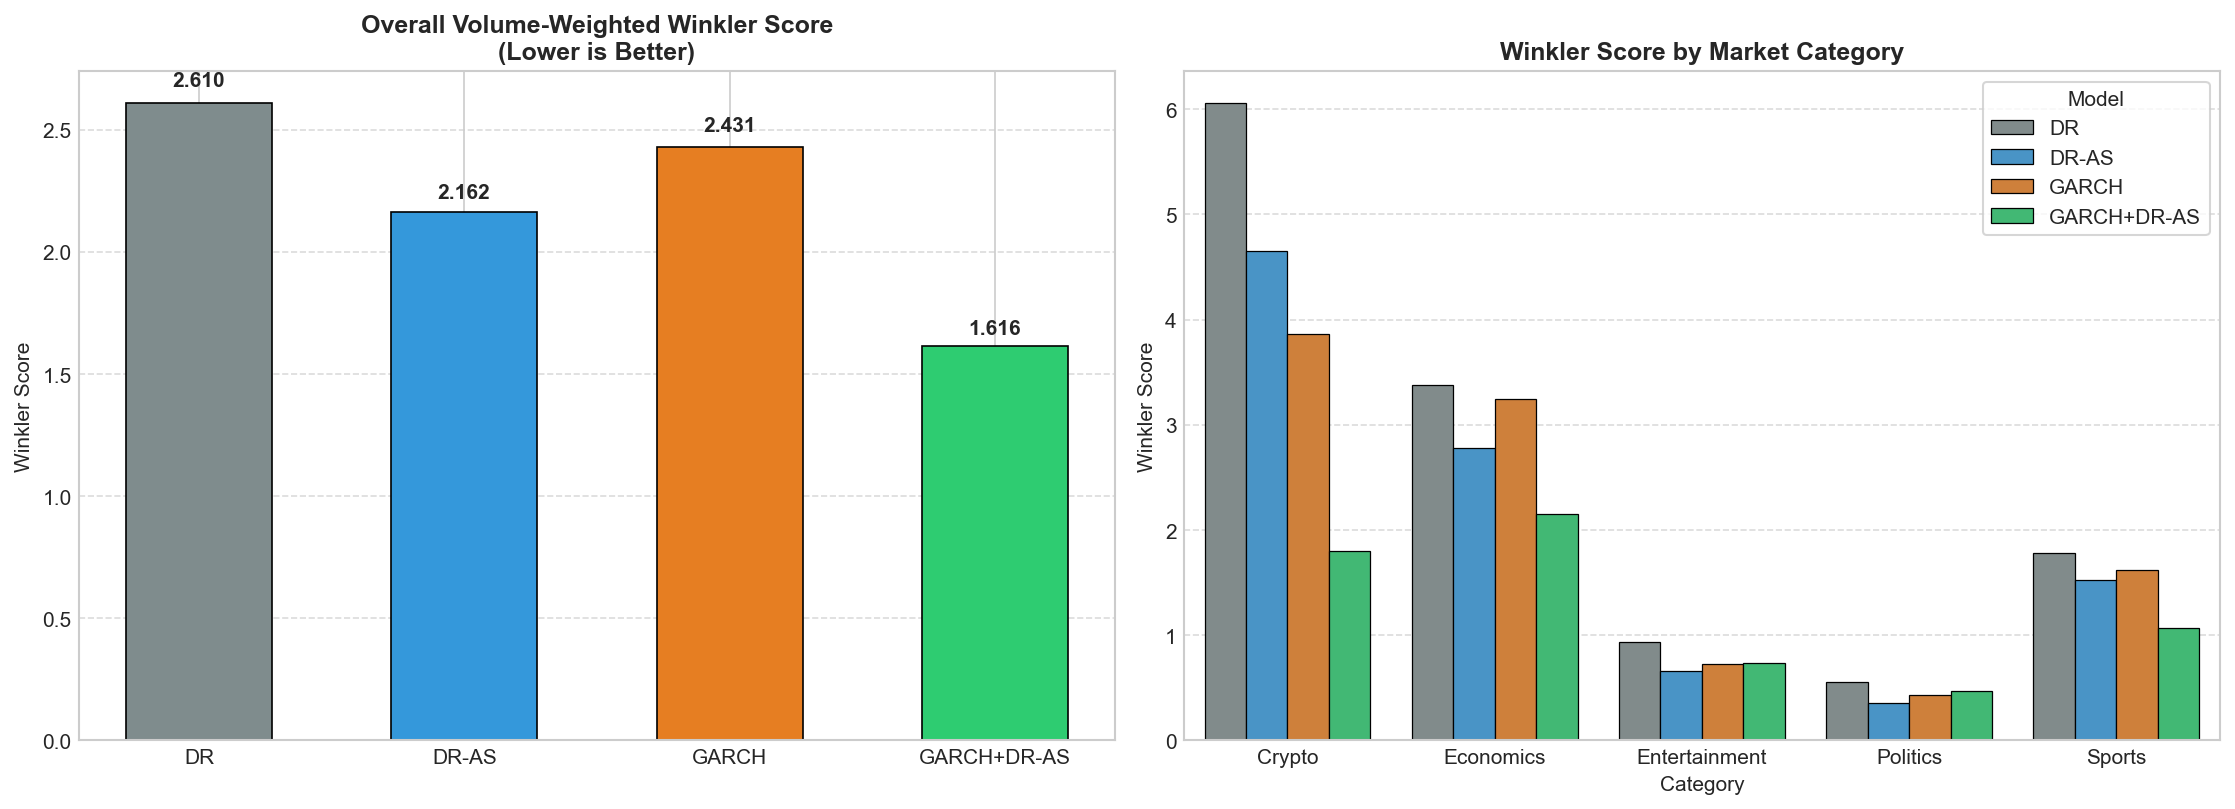

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Model color palette mapping
model_palette = {
    "DR": "#7f8c8d",          # Grey
    "DR-AS": "#3498db",       # Blue
    "GARCH": "#e67e22",       # Orange
    "GARCH+DR-AS": "#2ecc71"  # Green
}

# Overall Winkler Score Comparison Bar Chart
models_present = overall_summary_df.index.tolist()
colors = [model_palette.get(m, "#9b59b6") for m in models_present]

bars = axes[0].bar(
    models_present, 
    overall_summary_df["Volume-Weighted Winkler Score"], 
    color=colors, 
    width=0.55, 
    edgecolor="black", 
    linewidth=0.8
)

axes[0].set_title("Overall Volume-Weighted Winkler Score\n(Lower is Better)", fontweight="bold")
axes[0].set_ylabel("Winkler Score")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# Add exact value annotations on top of each bar
for bar in bars:
    yval = bar.get_height()
    axes[0].text(
        bar.get_x() + bar.get_width() / 2.0, 
        yval + (yval * 0.02), 
        f"{yval:.3f}", 
        ha="center", 
        va="bottom", 
        fontweight="bold"
    )

# Category-Level Winkler Score Comparison Bar Chart
sns.barplot(
    data=df_categories, 
    x="category", 
    y="winkler", 
    hue="model", 
    ax=axes[1], 
    palette=model_palette,
    edgecolor="black",
    linewidth=0.6
)

axes[1].set_title("Winkler Score by Market Category", fontweight="bold")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Winkler Score")
axes[1].legend(title="Model", frameon=True)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

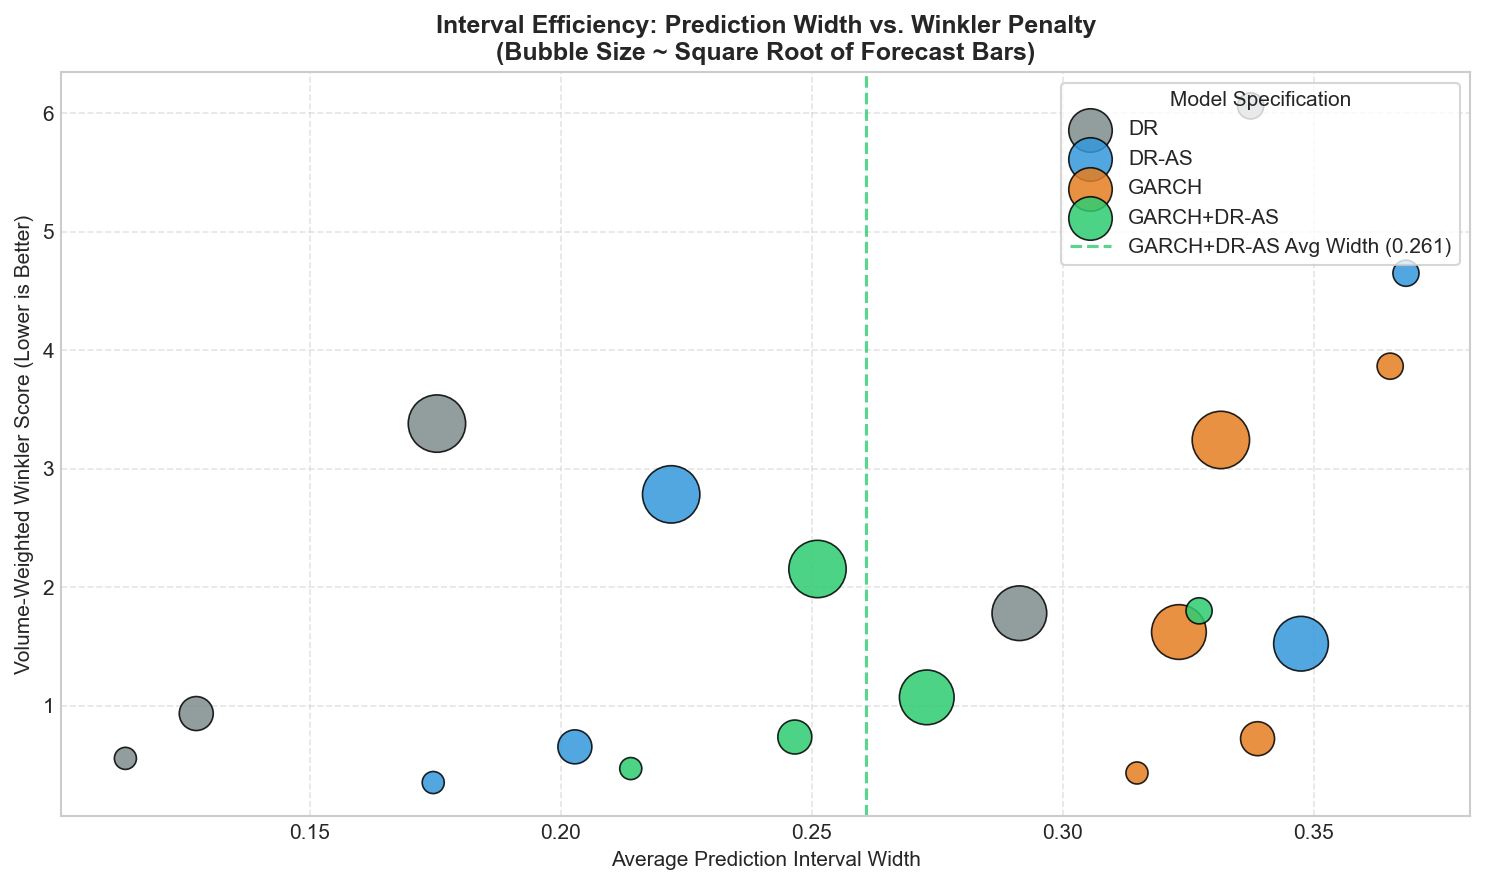

In [ ]:
plt.figure(figsize=(10, 6))

# Bubble scatter plot: Interval Width vs. Winkler Score
for model_name in df_categories["model"].unique():
    sub_df = df_categories[df_categories["model"] == model_name]
    plt.scatter(
        sub_df["width"], 
        sub_df["winkler"], 
        s=np.sqrt(sub_df["bars"]) * 2.5 + 40,  # Scaled by sample size
        alpha=0.85, 
        color=model_palette.get(model_name, "#9b59b6"), 
        label=model_name,
        edgecolor="black",
        linewidth=0.8
    )

# Highlight GARCH+DR-AS average width line dynamically
garch_dras_avg_width = overall_summary_df.loc["GARCH+DR-AS", "Average Interval Width"] if "GARCH+DR-AS" in overall_summary_df.index else None
if garch_dras_avg_width:
    plt.axvline(
        x=garch_dras_avg_width, 
        color="#2ecc71", 
        linestyle="--", 
        alpha=0.8, 
        label=f"GARCH+DR-AS Avg Width ({garch_dras_avg_width:.3f})"
    )

plt.title("Interval Efficiency: Prediction Width vs. Winkler Penalty\n(Bubble Size ~ Square Root of Forecast Bars)", fontweight="bold")
plt.xlabel("Average Prediction Interval Width")
plt.ylabel("Volume-Weighted Winkler Score (Lower is Better)")
plt.legend(title="Model Specification", frameon=True, loc="upper right")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()